## RDS Experiment

In [1]:
from syft_rds import init_session
from syft_core import Client
from syft_rds.orchestra import setup_rds_server
import os

In [2]:
ds_stack = setup_rds_server(email="ds@openmined.org", key="enclave")

os.environ["SYFTBOX_CLIENT_CONFIG_PATH"] = str(ds_stack.client.config_path)

2025-08-05 18:56:38.729 | INFO     | syft_rds.orchestra:setup_rds_server:221 - Launching mock RDS server in /private/var/folders/4w/9cvj7hqd4_386stwby6n2pcw0000gn/T/enclave


In [3]:
DATA_OWNERS = [
            "do1@openmined.org",
            "do2@openmined.org"
              ]
DATA_SCIENTIST = [ Client.load().email ]

In [4]:
ds_clients = []

for do in DATA_OWNERS:
    ds_client = init_session(do)
    ds_clients.append(ds_client)
    print(f"Logged into {ds_client.host}")


Logged into do1@openmined.org
Logged into do2@openmined.org


In [5]:
datasets = []

# We could either index the datasets
for ds_client in ds_clients:
    datasets.append(ds_client.datasets[0])
    
    

In [6]:
datasets

[Dataset
   uid: d548dea0-8177-4574-b7e4-eab0b3e1e4a1
   created_by: None
   created_at: 2025-08-05T13:15:00.246259Z
   updated_at: 2025-08-05T13:15:00.246266Z
   client_id: 52c57d85-90c8-4f1b-8140-fdb78d60a187
   name: GPT2 Model
   private: syft://do1@openmined.org/private/datasets/GPT2 Model
   mock: syft://do1@openmined.org/public/datasets/GPT2 Model
   summary: This Dataset contains the GPT2 Model
   readme: syft://do1@openmined.org/public/datasets/GPT2 Model/readme.md
   tags: []
   runtime: {'cmd': ['python'], 'image_name': None, 'mount_dir': None}
   auto_approval: [],
 Dataset
   uid: 8ed04b30-ff66-4ce0-b0ce-8bb4a45c394a
   created_by: None
   created_at: 2025-08-05T13:14:58.684095Z
   updated_at: 2025-08-05T13:14:58.684097Z
   client_id: b05f787e-4354-4796-b912-6ff0fa94fbff
   name: Prompts Dataset
   private: syft://do2@openmined.org/private/datasets/Prompts Dataset
   mock: syft://do2@openmined.org/public/datasets/Prompts Dataset
   summary: This dataset contains Name Promp

In [7]:
datasets[0].describe()

uid,d548dea0-8177-4574-b7e4-eab0b3e1e4a1
created_at,2025-08-05 13:15:00
updated_at,2025-08-05 13:15:00
name,GPT2 Model
readme_path,/private/var/folders/4w/9cvj7hqd4_386stwby6n2pcw0000gn/T/enclave/datasites/do1@openmined.org/public/datasets/GPT2 Model/readme.md
mock_path,/private/var/folders/4w/9cvj7hqd4_386stwby6n2pcw0000gn/T/enclave/datasites/do1@openmined.org/public/datasets/GPT2 Model
private_path,/private/var/folders/4w/9cvj7hqd4_386stwby6n2pcw0000gn/T/enclave/datasites/do1@openmined.org/private/datasets/GPT2 Model


In [8]:
datasets[1].describe()

uid,8ed04b30-ff66-4ce0-b0ce-8bb4a45c394a
created_at,2025-08-05 13:14:58
updated_at,2025-08-05 13:14:58
name,Prompts Dataset
readme_path,/private/var/folders/4w/9cvj7hqd4_386stwby6n2pcw0000gn/T/enclave/datasites/do2@openmined.org/public/datasets/Prompts Dataset/readme.md
mock_path,/private/var/folders/4w/9cvj7hqd4_386stwby6n2pcw0000gn/T/enclave/datasites/do2@openmined.org/public/datasets/Prompts Dataset
private_path,/private/var/folders/4w/9cvj7hqd4_386stwby6n2pcw0000gn/T/enclave/datasites/do2@openmined.org/private/datasets/Prompts Dataset


### Inspect the data and inform their analysis



In [9]:
# path = datasets[0].get_mock_path()
# !open -R "{path}"

In [10]:
# path = datasets[1].get_mock_path()
# !open -R "{path}"

### Propose analysis

In [11]:
from pathlib import Path

code_path = Path(".") / "code"
code_path.mkdir(exist_ok=True)

code_file_name  = "secure_inference.py"
code_file_path = code_path / code_file_name

In [12]:
%%writefile {code_file_path}

import os
from pathlib import Path
from sys import exit

import pandas as pd

DATA_DIR = os.environ["DATA_DIR"]
OUTPUT_DIR = os.environ["OUTPUT_DIR"]

model_folder, prompt_path = [ str(Path(path).resolve()) for path in  DATA_DIR.split(",")]
output_path = Path(OUTPUT_DIR) / "output.txt"


# third party
from transformers import AutoModelForCausalLM
from transformers import AutoTokenizer

model = AutoModelForCausalLM.from_pretrained(model_folder)
tokenizer = AutoTokenizer.from_pretrained(model_folder)
pad_token_id = (
    tokenizer.pad_token_id
    if tokenizer.pad_token_id
    else tokenizer.eos_token_id
)

def inference(prompt: str, raw=False, **kwargs) -> str:
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids
    gen_tokens = model.generate(
        input_ids,
        do_sample=True,
        temperature=0.9,
        max_length=100,
        pad_token_id=pad_token_id,
        **kwargs,
    )
    if raw:
        return gen_tokens
    else:
        gen_text = tokenizer.batch_decode(gen_tokens)[0]
        return gen_text

prompt_paths = list(Path(prompt_path).glob("*.txt"))  # list of txt files
prompts = []

for file_path in prompt_paths:
    with open(file_path, "r", encoding="utf-8") as f:
        prompts.extend(line.strip() for line in f)

# run inference & save
outputs = []
for prompt in prompts:
    print(f"Runing inference on prompt: {prompt}")
    output = inference(prompt)
    outputs.append(output)
    
output_path.write_text("\n\n".join(outputs) + "\n", encoding="utf-8")
print(f"Saved {len(outputs)} outputs to {output_path}")


Overwriting code/secure_inference.py


### Test the analysis code against mock data

Before submitting the code for review, Treasury can test their analysis against the Department of Health mock data to ensure it works correctly.


In [13]:
str(Path("./gpt2_mock").resolve())

'/Users/rasswanths/openmined/syftbox-enclave/notebooks/RDS-Eval/gpt2_mock'

In [14]:
# Test against mock of all datasets

import subprocess, tempfile, os
from IPython.display import display

with tempfile.TemporaryDirectory() as temp_dir:
    env = os.environ.copy()
    env.update({'DATA_DIR': "./gpt2_mock,./mock-name-prompt.txt", 'OUTPUT_DIR': temp_dir})
    
    result = subprocess.run(["python", str(code_file_path)], env=env, capture_output=True, text=True)
    import pdb
    pdb.set_trace()

    output_txt_path = Path(temp_dir) / "output.txt"
    for line in Path(output_txt_path).read_text(encoding="utf-8").splitlines():
        print(line.strip(), end="\n\n")

> /var/folders/4w/9cvj7hqd4_386stwby6n2pcw0000gn/T/ipykernel_7171/732718432.py(14)<module>()
     12     pdb.set_trace()
     13 
---> 14     output_txt_path = Path(temp_dir) / "output.txt"
     15     for line in Path(output_txt_path).read_text(encoding="utf-8").splitlines():
     16         print(line.strip(), end="\n\n")



ipdb>  result.stdout


'Saved 0 outputs to /var/folders/4w/9cvj7hqd4_386stwby6n2pcw0000gn/T/tmpol2clnyp/output.txt\n'


ipdb>  result.stderr


''
--KeyboardInterrupt--

KeyboardInterrupt: Interrupted by user




---
# 3. Researcher submits analysis code

Researcher submits the Analysis code to the Data Owners to be able to run on enclaves



In [ ]:
from uuid import uuid4

# Generate 
RANDOM_ID = str(uuid4())[0:8]
JOB_NAME = f"Test Job - {RANDOM_ID}"

print("Job Name:", JOB_NAME)

In [ ]:
ENCLAVE = "enclave@openmined.org"

jobs = []

for ds_client, dataset in zip(ds_clients, datasets):
    job = ds_client.jobs.submit(
                name=JOB_NAME,
                description="Prompt Evals Experiment",
                user_code_path=code_path,
                dataset_name=dataset.name,
                entrypoint = code_file_name,
                enclave = ENCLAVE
            )
    job.describe()
    jobs.append(job)

In [ ]:
ds_clients[1].jobs.get(name=JOB_NAME).describe()

## Enclave Client

In [ ]:
from syftbox_enclave import connect

In [ ]:
enclave_client = connect(ENCLAVE)

In [ ]:
PROJECT_NAME = f"Test Project - {RANDOM_ID}"

print("Project Name:", PROJECT_NAME)

In [ ]:
datasets

In [ ]:

proj_res = enclave_client.create_project(
                   project_name = PROJECT_NAME,
                   datasets = datasets,
                   output_owners = DATA_OWNERS + DATA_SCIENTIST,
                   code_path = code_path,
                   entrypoint = code_file_name,
            )

In [ ]:
proj_res.status(block=True)

In [ ]:
# Force Start if atleast one of the datasites have approved
# proj_res.force_start()

---
# 4. Researcher accesses approved results

After being executed in the enclave, the researcher access the output

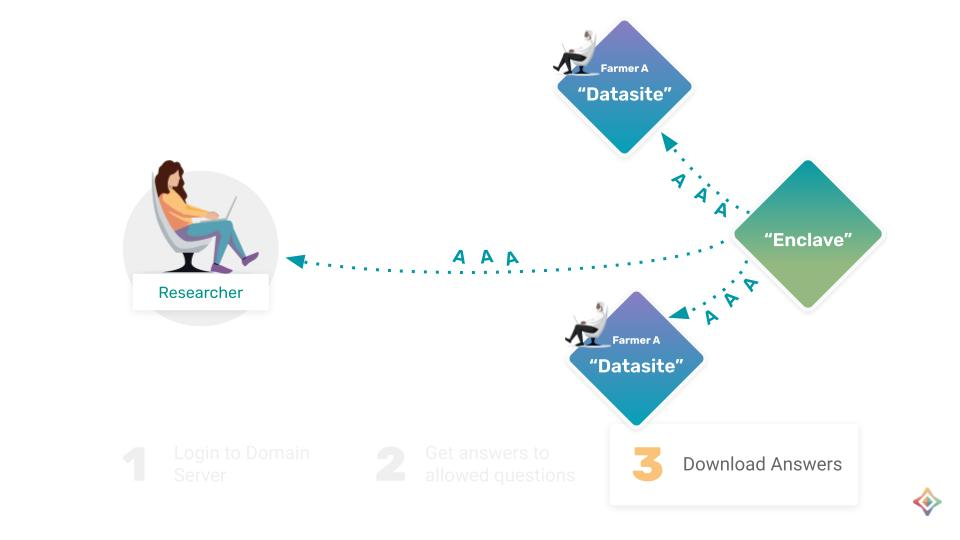

In [ ]:
# Wait until the project is ready
proj_res_path = proj_res.output(block=True)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# Set the path to the output.csv
output_csv_path = proj_res_path / "output.csv"

# Set up the plotting style
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Crop Stock Data Analysis', fontsize=16, fontweight='bold')

# Load data
if output_csv_path.exists():
    df = pd.read_csv(output_csv_path)

    # Positions for bars
    x = np.arange(len(df))  # [0, 1, 2, ...]
    width = 0.1

    # Plot bars with fixed width and controlled spacing
    bars = ax.bar(x, df["Quantity"], width=width, color=['#FF6B6B', '#4ECDC4'])

    ax.set_title('Current Stock of Crops by Type', fontweight='bold')
    ax.set_xlabel('Product Name')
    ax.set_ylabel('Quantity')

    # Set x-ticks to product names
    ax.set_xticks(x)
    ax.set_xticklabels(df["Product name"])
    ax.tick_params(axis='x', rotation=0)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height + 0.5,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No crop stock data available to visualize.")